# Notebook 1: Single Attribution Analysis

This notebook performs interpretability analysis on individual predictions:

1. **Section 1a**: Top/bottom prefixes by Brier score with attribution maps
2. **Section 1b**: Feature Importance by Prediction Quality (Normalized)
3. **Section 1c**: Top/bottom prefixes by certainty (Shannon Entropy) with attribution maps
4. **Section 1d**: Attribution Breakdown by Predicted Activity Class

In [1]:
import sys
import os
from pathlib import Path
import pickle
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Add src directory to path (robust path handling)
NOTEBOOK_DIR = Path().resolve()
SRC_DIR = NOTEBOOK_DIR.parent.parent  # interpretability/notebooks -> interpretability -> src
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
print(f"Source directory: {SRC_DIR}")

from aa_philipp.classes.suffix_samples import SuffixSamples
from aa_philipp.classes.sequence import Sequence
from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from aa_philipp.model_with_integrated_gradients.embedder import get_final_process_step
from aa_philipp.model_with_integrated_gradients.targeter import ActivityTargeter, TimeTargeter
from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_decoder_forward_simplified import PSP_Model_simplified
from evaluation.evaluation import Evaluation

from captum.attr import IntegratedGradients

# Set seeds for reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

Source directory: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src


## Load Model and Data

In [2]:
# Load model (paths relative to SRC_DIR)
file_path_model = SRC_DIR / 'notebooks/training_variational_dropout/Helpdesk/Helpdesk_full_grad_norm_philipp_4layer.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(file_path_model), dropout=0.0)
model.eval()

# Load test dataset
file_path_data_set = SRC_DIR.parent / 'encoded_data/test_philipp/helpdesk_all_5_test.pkl'
helpdesk_test_dataset = torch.load(str(file_path_data_set), weights_only=False)

print(f"Model loaded: {file_path_model}")
print(f"Dataset loaded: {len(helpdesk_test_dataset)} samples")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

In [3]:
# Load pre-computed inference results (from spread_analysis)
results_path = SRC_DIR / 'aa_philipp/notebooks/results_store_helpdesk_results.pkl'

with open(results_path, 'rb') as f:
    results_df = pickle.load(f)

results_df = pd.DataFrame(results_df)
print(f"Loaded {len(results_df)} inference results")
results_df.head()

Loaded 3329 inference results


,case_name,prefix_len,prefix,suffix,mean_prediction,predicted_suffixes,database_index
0,Case 4220,1,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Take in charge ticket', 'Resour...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[[{'Activity': 'Resolve ticket', 'Resource': '...",0
1,Case 4220,2,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[[{'Activity': 'Resolve ticket', 'Resource': '...",0
2,Case 4220,3,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Closed', 'Resource': 'Value 5',...","[{'Activity': 'Closed', 'Resource': 'Value 5',...","[[{'Activity': 'Closed', 'Resource': 'Value 5'...",0
3,Case 4461,1,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Take in charge ticket', 'Resour...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[[{'Activity': 'Take in charge ticket', 'Resou...",1
4,Case 4461,2,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[[{'Activity': 'Resolve ticket', 'Resource': '...",1


In [4]:
# Compute Brier score and Shannon entropy if not already present
if 'brier_score_activities' not in results_df.columns:
    print("Computing Brier scores...")
    results_df['brier_score_activities'] = results_df.apply(
        SuffixSamples.calculate_brier_score_full_suffix, axis=1
    )

if 'shannon_entropy_activities' not in results_df.columns:
    print("Computing Shannon entropy...")
    results_df['shannon_entropy_activities'] = results_df.apply(
        SuffixSamples.calculate_shannon_entropy_on_activity_suffix, axis=1
    )

# Compute actual suffix length
if 'actual_suffix_length' not in results_df.columns:
    def get_suffix_length(row):
        ss = SuffixSamples.from_row(row)
        return len(ss.suffix.event_list)
    results_df['actual_suffix_length'] = results_df.apply(get_suffix_length, axis=1)

print(f"Brier score range: [{results_df['brier_score_activities'].min():.3f}, {results_df['brier_score_activities'].max():.3f}]")
print(f"Shannon entropy range: [{results_df['shannon_entropy_activities'].min():.3f}, {results_df['shannon_entropy_activities'].max():.3f}]")

Computing Brier scores...
Computing Shannon entropy...
Brier score range: [0.000, 1.000]
Shannon entropy range: [-0.000, -0.000]


In [5]:
# Setup evaluation object for prefix iteration
evaluation = Evaluation(
    model=model,
    dataset=helpdesk_test_dataset,
    concept_name='Activity',
    growing_num_values=['case_elapsed_time'],
    all_cat=['Activity', 'Resource'],
    all_num=['case_elapsed_time', 'event_elapsed_time']
)

# Get prefix categories for attribution unpacking
prefix_cat_attributes = evaluation.prefix_cat_attributes
print(f"Categorical attributes: {prefix_cat_attributes}")

Categorical attributes: ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']


## Integrated Gradients Helper Functions

**Note on Convergence Delta**: This encoder-decoder architecture has separate embedding paths for the encoder (prefix) and decoder (SOS token). This architectural design creates challenges for Integrated Gradients' completeness axiom, which requires that:

`f(x) - f(baseline) = Σ attributions`

The convergence delta may be larger than ideal (> 0.1 in absolute value), but **relative attributions remain meaningful** for comparing feature importance within and across predictions. The absolute values should be interpreted with caution.

In [6]:
def forward_for_ig(model, prefix, target_fn):
    """Forward function for Integrated Gradients."""
    simplified_model = PSP_Model_simplified(model=model)
    predictions = simplified_model.forward(prefix=prefix)
    target = target_fn(predictions)
    return target


def compute_integrated_gradients(model, prefix, target_fn, n_steps=300, method='gausslegendre'):
    """
    Compute Integrated Gradients for a prefix.
    
    Note: This model has separate encoder/decoder embedding paths which creates
    challenges for IG's completeness axiom. The convergence delta may be larger
    than ideal, but relative attributions are still meaningful for comparison.
    
    Args:
        model: The trained model
        prefix: Input prefix tensor
        target_fn: Function to extract target output
        n_steps: Number of integration steps (higher = better convergence)
        method: Integration method ('gausslegendre' is most accurate)
    
    Returns:
        attributions: Tensor with shape [seq_len, batch, embed_dim]
        conv_delta: Convergence delta (ideally close to 0, but may be larger 
                    due to architectural limitations)
    """
    # Encode prefix as model input
    prefixes_embedded = model.encoder.data_enc_for_model(data=prefix)
    prefixes_embedded = prefixes_embedded.detach()
    prefixes_embedded.requires_grad_(True)

    sos_event = get_final_process_step(prefix)
    final_prefix_element_embedded = model.decoder.data_enc_for_model(data=sos_event, pred=False)
    final_prefix_element_embedded = final_prefix_element_embedded.detach()
    final_prefix_element_embedded.requires_grad_(True)

    baselines = (
        torch.zeros_like(prefixes_embedded),
        torch.zeros_like(final_prefix_element_embedded)
    )

    ig = IntegratedGradients(
        lambda x1, x2: forward_for_ig(
            model=model,
            prefix=(x1, x2),
            target_fn=target_fn,
        ),
    )

    attributions, conv_delta = ig.attribute(
        inputs=(prefixes_embedded, final_prefix_element_embedded),
        baselines=baselines,
        n_steps=n_steps,
        method=method,
        internal_batch_size=1,  # Process one step at a time for numerical stability
        return_convergence_delta=True
    )

    # Merge encoder and decoder attributions
    # The decoder's SOS event attribution is added to the encoder's last timestep
    # Note: This merging is necessary due to the separate encoder/decoder architecture
    # but may not fully satisfy IG's completeness axiom
    seq_len = prefixes_embedded.shape[0]
    embed_dim = min(attributions[0].shape[2], attributions[1].shape[2])
    attributions[0][seq_len - 1, :, :embed_dim] += attributions[1][0, :, :embed_dim]

    return attributions[0], conv_delta


def full_forward(model, prefix):
    """Get full model prediction for a prefix."""
    prefixes_embedded = model.encoder.data_enc_for_model(data=prefix)
    prefixes_embedded = prefixes_embedded.detach()
    prefixes_embedded.requires_grad_(True)

    sos_event = get_final_process_step(prefix)
    final_prefix_element_embedded = model.decoder.data_enc_for_model(data=sos_event, pred=False)
    final_prefix_element_embedded = final_prefix_element_embedded.detach()
    final_prefix_element_embedded.requires_grad_(True)

    pred = forward_for_ig(
        model=model,
        prefix=(prefixes_embedded, final_prefix_element_embedded),
        target_fn=lambda x: x,
    )
    return pred

In [7]:
def unpack_attribution(sample_tensor, model, prefix_cat_attributes):
    """
    Unpack attribution tensor back to feature space.
    
    Args:
        sample_tensor: Attribution tensor for a single timestep [embed_dim]
        model: The model (for embedding dimensions)
        prefix_cat_attributes: List of categorical attribute names
    
    Returns:
        dict: Feature name -> mean attribution value
    """
    start_index = 0
    attribution_dict = {}

    for idx, encoded_attribute in enumerate(prefix_cat_attributes):
        embedding_dim = model.encoder.embeddings[idx].embedding_dim
        attr_slice = sample_tensor[start_index:start_index + embedding_dim]
        attribution_dict[encoded_attribute] = attr_slice.mean().item()
        start_index += embedding_dim

    return attribution_dict


def get_attribution_for_prefix(attribution_tensor, prefix_len, model, prefix_cat_attributes):
    """
    Extract and unpack attributions for actual prefix timesteps.
    
    Returns:
        list of dicts: One dict per timestep with feature attributions
    """
    attribution_tensor = attribution_tensor.squeeze(1)  # Remove batch dim
    attribution_list = []
    
    # Only take the last prefix_len timesteps (excluding padding)
    for time_step in attribution_tensor[-prefix_len:]:
        attr = unpack_attribution(time_step, model, prefix_cat_attributes)
        attribution_list.append(attr)
    
    return attribution_list

In [8]:
def visualize_attribution_heatmap(attribution_list, title="Attribution Heatmap", ax=None):
    """
    Create a heatmap visualization of attributions.
    
    Args:
        attribution_list: List of dicts, one per timestep
        title: Plot title
        ax: Matplotlib axis (creates new if None)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    
    # Convert to DataFrame
    df_attr = pd.DataFrame(attribution_list)
    
    # Plot heatmap
    sns.heatmap(
        df_attr.T,
        center=0,
        cmap='RdBu_r',
        annot=True,
        fmt='.3f',
        ax=ax,
        cbar_kws={'label': 'Attribution'}
    )
    ax.set_xlabel('Prefix Timestep')
    ax.set_ylabel('Feature')
    ax.set_title(title)
    ax.set_xticklabels([f't{i+1}' for i in range(len(attribution_list))])
    
    return ax


def display_case_info(row, suffix_samples=None):
    """Display information about a case."""
    if suffix_samples is None:
        suffix_samples = SuffixSamples.from_row(row)
    
    print(f"Case: {row['case_name']}")
    print(f"Prefix Length: {row['prefix_len']}")
    print(f"Brier Score: {row['brier_score_activities']:.4f}")
    print(f"Shannon Entropy: {row['shannon_entropy_activities']:.4f}")
    print(f"\nPrefix Events:")
    for i, event in enumerate(suffix_samples.prefix.event_list):
        print(f"  {i+1}. {event.activity}")
    print(f"\nTrue Suffix:")
    for i, event in enumerate(suffix_samples.suffix.event_list):
        print(f"  {i+1}. {event.activity}")
    print(f"\nMean Prediction:")
    for i, event in enumerate(suffix_samples.mean_prediction.event_list):
        print(f"  {i+1}. {event.activity}")

In [9]:
def get_prefix_tensor_from_row(row, evaluation):
    """
    Get the prefix tensor for a row from the results dataframe.
    
    This reconstructs the prefix by finding the matching case and prefix_len
    in the evaluation dataset.
    """
    case_name = row['case_name']
    prefix_len = row['prefix_len']
    
    # Find the case in the evaluation
    cases = evaluation._get_cases_from_dataset()
    
    if case_name not in evaluation.cases:
        raise ValueError(f"Case {case_name} not found in dataset")
    
    full_case = evaluation.cases[case_name]
    
    # Iterate to find the matching prefix length
    for pl, prefix, suffix in evaluation._iterate_case(full_case):
        if pl == prefix_len:
            return prefix
    
    raise ValueError(f"Prefix length {prefix_len} not found for case {case_name}")

---
## Section 1a: Top/Bottom Prefixes by Brier Score

We select the 5 best-performing (lowest Brier score) and 5 worst-performing (highest Brier score) prefixes, then compute and visualize their attribution maps.

In [10]:
# Select top 5 (best) and bottom 5 (worst) by Brier score
# Filter out NaN values and ensure we have valid samples
valid_df = results_df.dropna(subset=['brier_score_activities'])

# For more interesting analysis, filter to prefixes with length >= 2
valid_df = valid_df[valid_df['prefix_len'] >= 2]

# Get top 5 (lowest Brier = best predictions)
top5_brier = valid_df.nsmallest(5, 'brier_score_activities')

# Get bottom 5 (highest Brier = worst predictions)
bottom5_brier = valid_df.nlargest(5, 'brier_score_activities')

print("=== TOP 5 (Best Predictions - Lowest Brier Score) ===")
print(top5_brier[['case_name', 'prefix_len', 'brier_score_activities', 'shannon_entropy_activities']].to_string())

print("\n=== BOTTOM 5 (Worst Predictions - Highest Brier Score) ===")
print(bottom5_brier[['case_name', 'prefix_len', 'brier_score_activities', 'shannon_entropy_activities']].to_string())

=== TOP 5 (Best Predictions - Lowest Brier Score) ===
   case_name  prefix_len  brier_score_activities  shannon_entropy_activities
1  Case 4220           2                     0.0                        -0.0
2  Case 4220           3                     0.0                        -0.0
4  Case 4461           2                     0.0                        -0.0
5  Case 4461           3                     0.0                        -0.0
9   Case 826           4                     0.0                        -0.0

=== BOTTOM 5 (Worst Predictions - Highest Brier Score) ===
    case_name  prefix_len  brier_score_activities  shannon_entropy_activities
7    Case 826           2                     1.0                        -0.0
8    Case 826           3                     1.0                        -0.0
11   Case 510           2                     1.0                        -0.0
12   Case 510           3                     1.0                        -0.0
21  Case 3185           2         

In [11]:
def analyze_prefix_attributions(row, model, evaluation, prefix_cat_attributes, 
                                  n_steps=300, method='gausslegendre'):
    """
    Compute attributions and create visualization for a single prefix.
    
    Args:
        row: DataFrame row with case info
        model: The trained model
        evaluation: Evaluation object for prefix extraction
        prefix_cat_attributes: List of categorical attribute names
        n_steps: Number of integration steps (300+ recommended)
        method: Integration method ('gausslegendre' is most accurate)
    
    Returns:
        dict with attribution_list, predictions, and metadata
    """
    # Get prefix tensor
    prefix = get_prefix_tensor_from_row(row, evaluation)
    prefix_len = row['prefix_len']
    
    # Get model prediction
    pred = full_forward(model, prefix)
    activity_prediction_idx = pred[0][0]["Activity_mean"][0].argmax().item()
    
    # Compute IG for predicted activity
    activity_targeter = ActivityTargeter(activity_index=activity_prediction_idx)
    attributions, conv_delta = compute_integrated_gradients(
        model=model,
        prefix=prefix,
        target_fn=activity_targeter.target_fn,
        n_steps=n_steps,
        method=method
    )
    
    # Extract convergence delta value
    delta_val = conv_delta.item() if hasattr(conv_delta, 'item') else float(conv_delta)
    
    # Unpack attributions
    attribution_list = get_attribution_for_prefix(
        attributions, prefix_len, model, prefix_cat_attributes
    )
    
    return {
        'attribution_list': attribution_list,
        'predicted_activity_idx': activity_prediction_idx,
        'convergence_delta': delta_val,
        'prefix_len': prefix_len
    }

TOP 5 PREDICTIONS (Lowest Brier Score - Best Performance)

────────────────────────────────────────────────────────────
CASE 1
────────────────────────────────────────────────────────────
Case: Case 4220
Prefix Length: 2
Brier Score: 0.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.816568


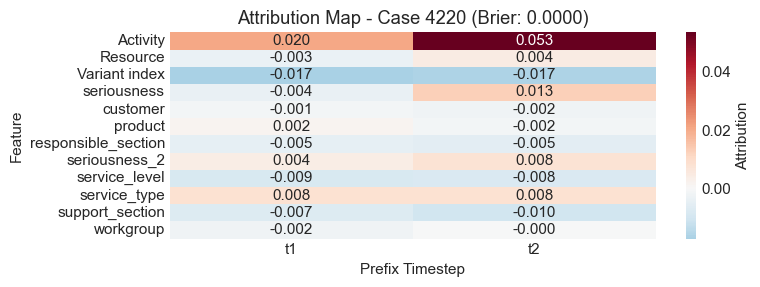


────────────────────────────────────────────────────────────
CASE 2
────────────────────────────────────────────────────────────
Case: Case 4220
Prefix Length: 3
Brier Score: 0.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket
  3. Resolve ticket

True Suffix:
  1. Closed

Mean Prediction:
  1. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -1.245179


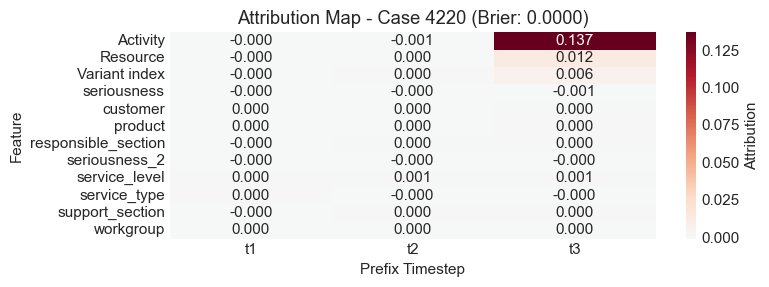


────────────────────────────────────────────────────────────
CASE 3
────────────────────────────────────────────────────────────
Case: Case 4461
Prefix Length: 2
Brier Score: 0.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.719416


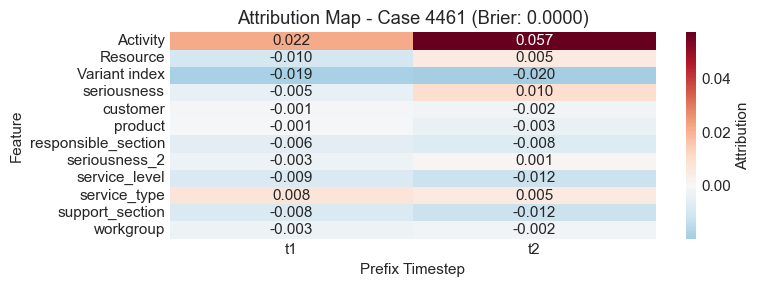


────────────────────────────────────────────────────────────
CASE 4
────────────────────────────────────────────────────────────
Case: Case 4461
Prefix Length: 3
Brier Score: 0.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket
  3. Resolve ticket

True Suffix:
  1. Closed

Mean Prediction:
  1. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -1.185359


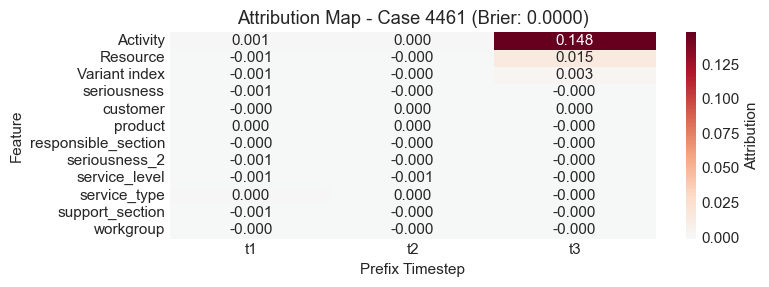


────────────────────────────────────────────────────────────
CASE 5
────────────────────────────────────────────────────────────
Case: Case 826
Prefix Length: 4
Brier Score: 0.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket
  3. None
  4. Resolve ticket

True Suffix:
  1. Closed

Mean Prediction:
  1. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -1.144731


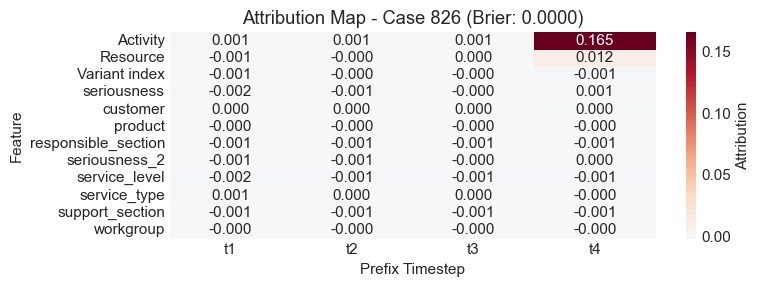

In [12]:
print("=" * 80)
print("TOP 5 PREDICTIONS (Lowest Brier Score - Best Performance)")
print("=" * 80)

for idx, (_, row) in enumerate(top5_brier.iterrows()):
    print(f"\n{'─' * 60}")
    print(f"CASE {idx + 1}")
    print(f"{'─' * 60}")
    
    # Display case info
    display_case_info(row)
    
    # Compute and visualize attributions
    try:
        result = analyze_prefix_attributions(row, model, evaluation, prefix_cat_attributes)
        print(f"\nConvergence Delta: {result['convergence_delta']:.6f}")
        
        # Create visualization
        fig, ax = plt.subplots(figsize=(max(8, result['prefix_len'] * 2), 3))
        visualize_attribution_heatmap(
            result['attribution_list'],
            title=f"Attribution Map - {row['case_name']} (Brier: {row['brier_score_activities']:.4f})",
            ax=ax
        )
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error computing attributions: {e}")

BOTTOM 5 PREDICTIONS (Highest Brier Score - Worst Performance)

────────────────────────────────────────────────────────────
CASE 1
────────────────────────────────────────────────────────────
Case: Case 826
Prefix Length: 2
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. None
  2. Resolve ticket
  3. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -1.105448


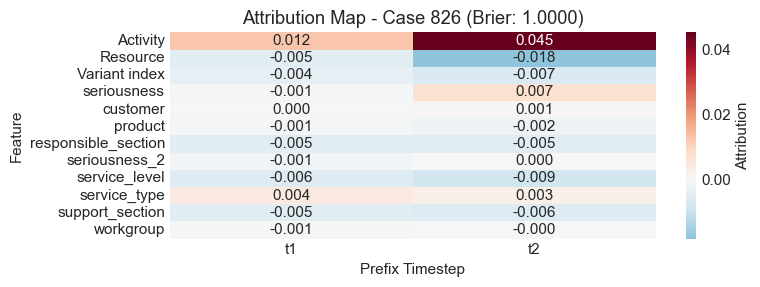


────────────────────────────────────────────────────────────
CASE 2
────────────────────────────────────────────────────────────
Case: Case 826
Prefix Length: 3
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket
  3. None

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.695878


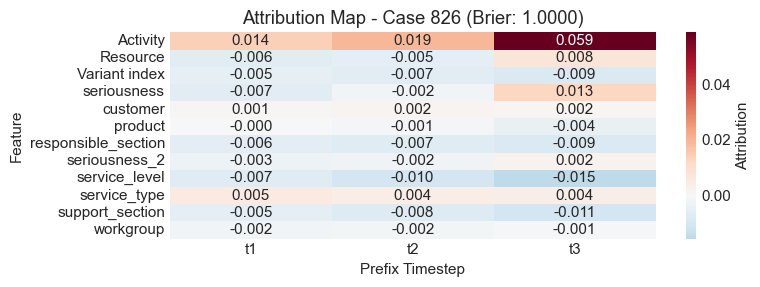


────────────────────────────────────────────────────────────
CASE 3
────────────────────────────────────────────────────────────
Case: Case 510
Prefix Length: 2
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. None
  2. Resolve ticket
  3. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.894557


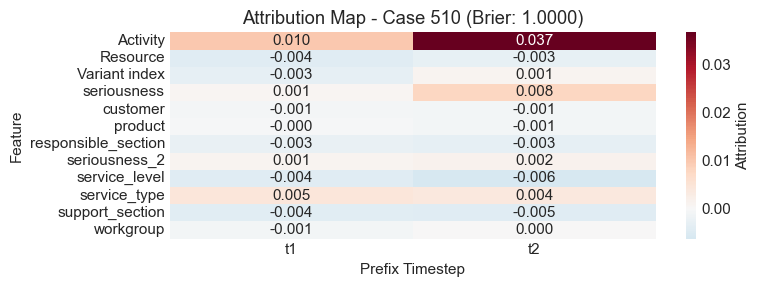


────────────────────────────────────────────────────────────
CASE 4
────────────────────────────────────────────────────────────
Case: Case 510
Prefix Length: 3
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket
  3. None

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.710742


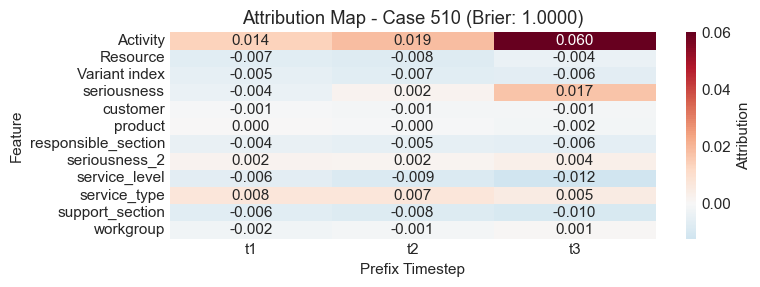


────────────────────────────────────────────────────────────
CASE 5
────────────────────────────────────────────────────────────
Case: Case 3185
Prefix Length: 2
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. Create SW anomaly
  2. Resolve ticket
  3. Closed

Mean Prediction:
  1. Take in charge ticket
  2. Take in charge ticket
  3. Resolve ticket
  4. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -2.281129


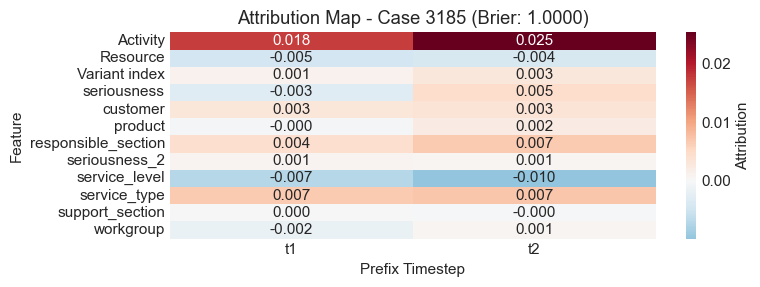

In [13]:
print("=" * 80)
print("BOTTOM 5 PREDICTIONS (Highest Brier Score - Worst Performance)")
print("=" * 80)

for idx, (_, row) in enumerate(bottom5_brier.iterrows()):
    print(f"\n{'─' * 60}")
    print(f"CASE {idx + 1}")
    print(f"{'─' * 60}")
    
    # Display case info
    display_case_info(row)
    
    # Compute and visualize attributions
    try:
        result = analyze_prefix_attributions(row, model, evaluation, prefix_cat_attributes)
        print(f"\nConvergence Delta: {result['convergence_delta']:.6f}")
        
        # Create visualization
        fig, ax = plt.subplots(figsize=(max(8, result['prefix_len'] * 2), 3))
        visualize_attribution_heatmap(
            result['attribution_list'],
            title=f"Attribution Map - {row['case_name']} (Brier: {row['brier_score_activities']:.4f})",
            ax=ax
        )
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error computing attributions: {e}")

---
## Section 1b: Feature Importance by Prediction Quality (Normalized)

We aggregate attributions across all prefixes, grouped by prediction quality (Brier score quartiles), to see if certain features are more important for accurate predictions.

In [14]:
# Try to load pre-computed IG results if available
ig_results_path = SRC_DIR / 'aa_philipp/notebooks/results_store_integrated_gradients_helpdesk_on_case_elapsed_time_and_attributions_predicted_activity.pkl'

try:
    with open(ig_results_path, 'rb') as f:
        ig_results_df = pickle.load(f)
    ig_results_df = pd.DataFrame(ig_results_df)
    print(f"Loaded {len(ig_results_df)} pre-computed IG results")
    use_precomputed = True
except FileNotFoundError:
    print("Pre-computed IG results not found. Will compute on sample.")
    use_precomputed = False

Loaded 6 pre-computed IG results


In [15]:
# If we don't have precomputed results, compute for a sample
if not use_precomputed:
    # Sample 100 prefixes stratified by Brier score
    sample_size = 100
    sample_df = valid_df.sample(n=min(sample_size, len(valid_df)), random_state=SEED)
    
    attribution_results = []
    
    for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Computing attributions"):
        try:
            result = analyze_prefix_attributions(row, model, evaluation, prefix_cat_attributes, n_steps=50)
            attribution_results.append({
                'case_name': row['case_name'],
                'prefix_len': row['prefix_len'],
                'brier_score': row['brier_score_activities'],
                'shannon_entropy': row['shannon_entropy_activities'],
                'attribution_list': result['attribution_list']
            })
        except Exception as e:
            print(f"Error for {row['case_name']}: {e}")
    
    attribution_df = pd.DataFrame(attribution_results)
else:
    # Use pre-computed results - merge with main results for Brier/entropy
    attribution_df = ig_results_df.merge(
        results_df[['case_name', 'prefix_len', 'brier_score_activities', 'shannon_entropy_activities']],
        on=['case_name', 'prefix_len'],
        how='inner'
    )
    attribution_df = attribution_df.rename(columns={
        'brier_score_activities': 'brier_score',
        'shannon_entropy_activities': 'shannon_entropy'
    })
    print(f"Merged {len(attribution_df)} records")

Merged 6 records


In [16]:
def extract_feature_attributions(row, prefix_cat_attributes, model):
    """
    Extract aggregated feature attributions from a row.
    Handles both pre-computed tensors and attribution lists.
    """
    # Check if we have pre-computed tensor or attribution list
    if 'attributions_predicted_activity' in row.index:
        # Pre-computed tensor format
        attr_tensor = row['attributions_predicted_activity']
        prefix_len = row['prefix_len']
        
        # Handle nested tensor structure
        if hasattr(attr_tensor, 'squeeze'):
            attr_tensor = attr_tensor.squeeze()
        
        # Get attribution list
        try:
            attribution_list = get_attribution_for_prefix(
                attr_tensor, prefix_len, model, prefix_cat_attributes
            )
        except Exception:
            return None
    elif 'attribution_list' in row.index:
        attribution_list = row['attribution_list']
    else:
        return None
    
    if attribution_list is None or len(attribution_list) == 0:
        return None
    
    # Aggregate: mean absolute attribution per feature across timesteps
    feature_attrs = {}
    for attr_dict in attribution_list:
        for feature, value in attr_dict.items():
            if feature not in feature_attrs:
                feature_attrs[feature] = []
            feature_attrs[feature].append(abs(value))
    
    # Mean across timesteps
    return {k: np.mean(v) for k, v in feature_attrs.items()}

In [17]:
# Create Brier score quartiles
attribution_df['brier_quartile'] = pd.qcut(
    attribution_df['brier_score'].rank(method='first'),
    q=4,
    labels=['Q1 (Best)', 'Q2', 'Q3', 'Q4 (Worst)']
)

print("Samples per quartile:")
print(attribution_df['brier_quartile'].value_counts().sort_index())

Samples per quartile:
brier_quartile
Q1 (Best)     2
Q2            1
Q3            1
Q4 (Worst)    2
Name: count, dtype: int64


In [18]:
# Aggregate attributions by quartile
quartile_features = {}

for quartile in ['Q1 (Best)', 'Q2', 'Q3', 'Q4 (Worst)']:
    quartile_df = attribution_df[attribution_df['brier_quartile'] == quartile]
    
    all_features = []
    for _, row in quartile_df.iterrows():
        features = extract_feature_attributions(row, prefix_cat_attributes, model)
        if features is not None:
            all_features.append(features)
    
    if all_features:
        # Average across all samples in quartile
        feature_names = all_features[0].keys()
        quartile_features[quartile] = {
            feat: np.mean([f[feat] for f in all_features if feat in f])
            for feat in feature_names
        }

print("Feature attributions by quartile:")
for q, feats in quartile_features.items():
    print(f"\n{q}:")
    for f, v in feats.items():
        print(f"  {f}: {v:.6f}")

Feature attributions by quartile:

Q1 (Best):
  Activity: 0.002983
  Resource: 0.001267
  Variant index: 0.000148
  seriousness: 0.000001
  customer: 0.000000
  product: 0.000000
  responsible_section: 0.000001
  seriousness_2: 0.000001
  service_level: 0.000001
  service_type: 0.000000
  support_section: 0.000001
  workgroup: 0.000001

Q2:
  Activity: 0.002753
  Resource: 0.001446
  Variant index: 0.000765
  seriousness: 0.000001
  customer: 0.000000
  product: 0.000000
  responsible_section: 0.000000
  seriousness_2: 0.000000
  service_level: 0.000000
  service_type: 0.000000
  support_section: 0.000000
  workgroup: 0.000000

Q3:
  Activity: 0.004811
  Resource: 0.001262
  Variant index: 0.000211
  seriousness: 0.000001
  customer: 0.000000
  product: 0.000001
  responsible_section: 0.000001
  seriousness_2: 0.000000
  service_level: 0.000000
  service_type: 0.000001
  support_section: 0.000001
  workgroup: 0.000000

Q4 (Worst):
  Activity: 0.000909
  Resource: 0.000253
  Variant ind

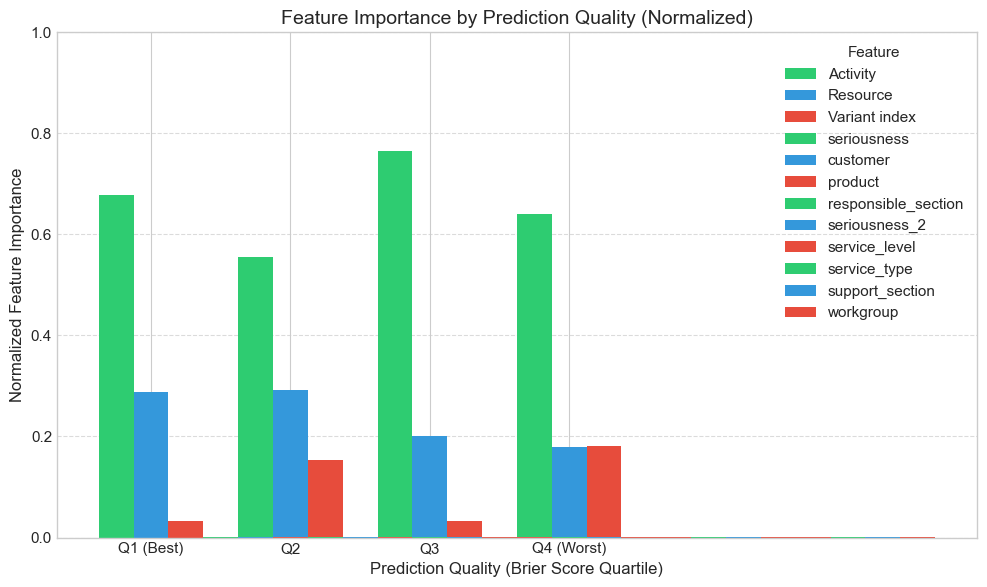

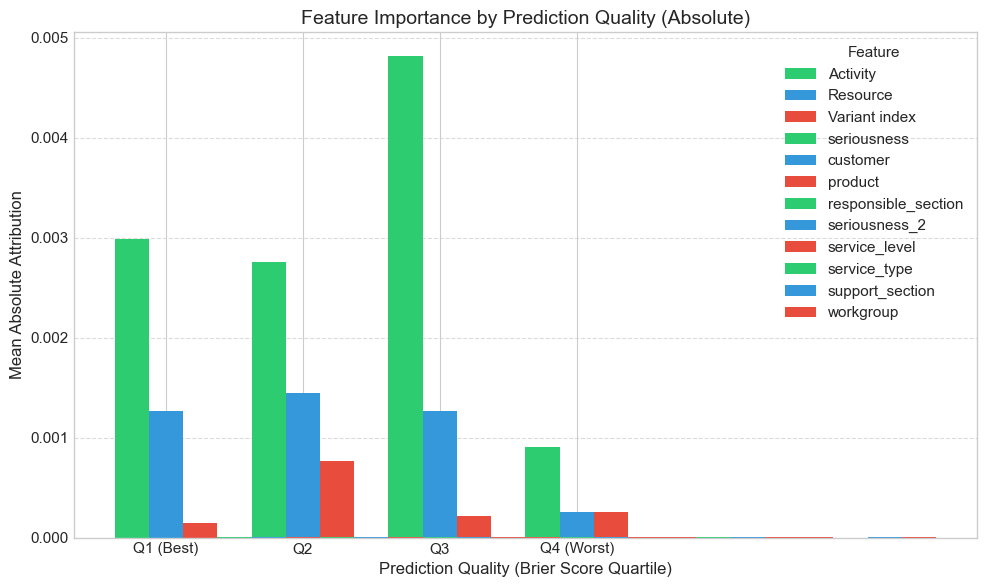

In [19]:
# Create normalized bar chart
if quartile_features:
    # Prepare data for plotting
    quartiles = list(quartile_features.keys())
    features = list(quartile_features[quartiles[0]].keys())
    
    # Build matrix and normalize per quartile
    data_matrix = []
    for q in quartiles:
        values = [quartile_features[q].get(f, 0) for f in features]
        total = sum(values) if sum(values) > 0 else 1
        normalized = [v / total for v in values]
        data_matrix.append(normalized)
    
    # Plot
    x = np.arange(len(quartiles))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['#2ecc71', '#3498db', '#e74c3c']  # Green, Blue, Red
    
    for i, feature in enumerate(features):
        values = [data_matrix[j][i] for j in range(len(quartiles))]
        bars = ax.bar(x + i * width, values, width, label=feature, color=colors[i % len(colors)])
    
    ax.set_xlabel('Prediction Quality (Brier Score Quartile)', fontsize=12)
    ax.set_ylabel('Normalized Feature Importance', fontsize=12)
    ax.set_title('Feature Importance by Prediction Quality (Normalized)', fontsize=14)
    ax.set_xticks(x + width)
    ax.set_xticklabels(quartiles)
    ax.legend(title='Feature')
    ax.set_ylim(0, 1)
    
    # Add grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Also show absolute values
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, feature in enumerate(features):
        values = [quartile_features[q].get(feature, 0) for q in quartiles]
        bars = ax.bar(x + i * width, values, width, label=feature, color=colors[i % len(colors)])
    
    ax.set_xlabel('Prediction Quality (Brier Score Quartile)', fontsize=12)
    ax.set_ylabel('Mean Absolute Attribution', fontsize=12)
    ax.set_title('Feature Importance by Prediction Quality (Absolute)', fontsize=14)
    ax.set_xticks(x + width)
    ax.set_xticklabels(quartiles)
    ax.legend(title='Feature')
    
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("No attribution data available for plotting.")

---
## Section 1c: Top/Bottom Prefixes by Certainty (Shannon Entropy)

We select prefixes with the lowest entropy (most certain) and highest entropy (least certain), controlling for suffix length to avoid confounding.

In [20]:
# Filter to medium-length suffixes to control for confounding
# (Entropy strongly correlates with suffix length)
medium_suffix_df = valid_df[
    (valid_df['actual_suffix_length'] >= 2) & 
    (valid_df['actual_suffix_length'] <= 4)
]

print(f"Filtered to {len(medium_suffix_df)} prefixes with suffix length 2-4")

# Get top 5 most certain (lowest entropy)
top5_certain = medium_suffix_df.nsmallest(5, 'shannon_entropy_activities')

# Get bottom 5 least certain (highest entropy)
bottom5_certain = medium_suffix_df.nlargest(5, 'shannon_entropy_activities')

print("\n=== TOP 5 (Most Certain - Lowest Entropy) ===")
print(top5_certain[['case_name', 'prefix_len', 'actual_suffix_length', 'shannon_entropy_activities', 'brier_score_activities']].to_string())

print("\n=== BOTTOM 5 (Least Certain - Highest Entropy) ===")
print(bottom5_certain[['case_name', 'prefix_len', 'actual_suffix_length', 'shannon_entropy_activities', 'brier_score_activities']].to_string())

Filtered to 1383 prefixes with suffix length 2-4

=== TOP 5 (Most Certain - Lowest Entropy) ===
    case_name  prefix_len  actual_suffix_length  shannon_entropy_activities  brier_score_activities
1   Case 4220           2                     2                        -0.0                     0.0
4   Case 4461           2                     2                        -0.0                     0.0
7    Case 826           2                     3                        -0.0                     1.0
8    Case 826           3                     2                        -0.0                     1.0
11   Case 510           2                     3                        -0.0                     1.0

=== BOTTOM 5 (Least Certain - Highest Entropy) ===
    case_name  prefix_len  actual_suffix_length  shannon_entropy_activities  brier_score_activities
1   Case 4220           2                     2                        -0.0                     0.0
4   Case 4461           2                     2     

TOP 5 MOST CERTAIN PREDICTIONS (Lowest Shannon Entropy)

────────────────────────────────────────────────────────────
CASE 1
────────────────────────────────────────────────────────────
Case: Case 4220
Prefix Length: 2
Brier Score: 0.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.816568


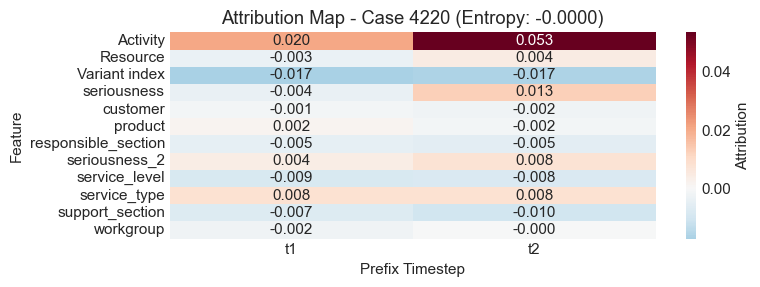


────────────────────────────────────────────────────────────
CASE 2
────────────────────────────────────────────────────────────
Case: Case 4461
Prefix Length: 2
Brier Score: 0.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.719416


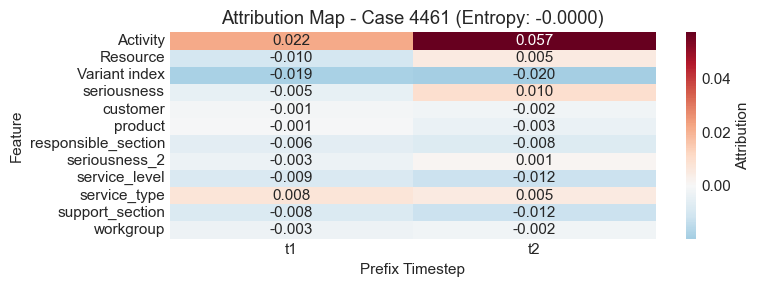


────────────────────────────────────────────────────────────
CASE 3
────────────────────────────────────────────────────────────
Case: Case 826
Prefix Length: 2
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. None
  2. Resolve ticket
  3. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -1.105448


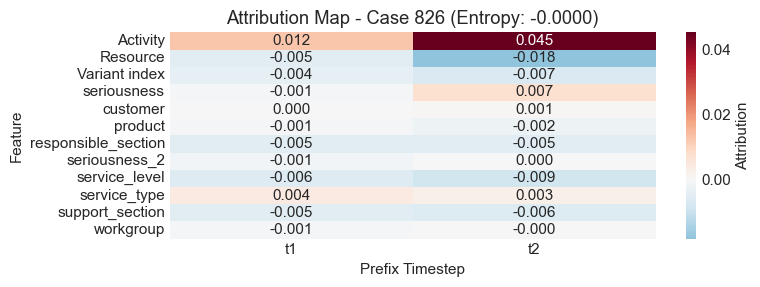


────────────────────────────────────────────────────────────
CASE 4
────────────────────────────────────────────────────────────
Case: Case 826
Prefix Length: 3
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket
  3. None

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.695878


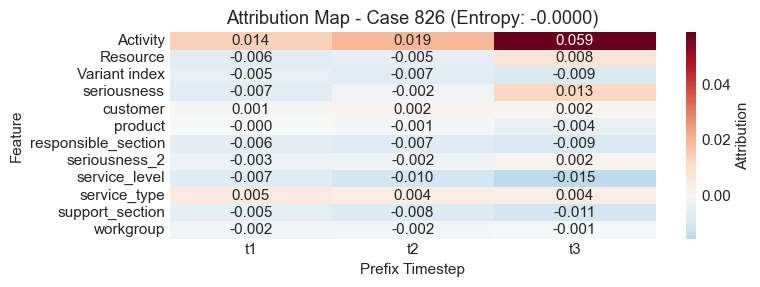


────────────────────────────────────────────────────────────
CASE 5
────────────────────────────────────────────────────────────
Case: Case 510
Prefix Length: 2
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. None
  2. Resolve ticket
  3. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.894557


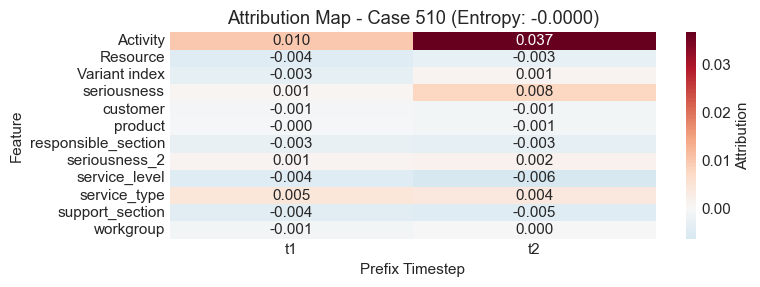

In [21]:
print("=" * 80)
print("TOP 5 MOST CERTAIN PREDICTIONS (Lowest Shannon Entropy)")
print("=" * 80)

for idx, (_, row) in enumerate(top5_certain.iterrows()):
    print(f"\n{'─' * 60}")
    print(f"CASE {idx + 1}")
    print(f"{'─' * 60}")
    
    display_case_info(row)
    
    try:
        result = analyze_prefix_attributions(row, model, evaluation, prefix_cat_attributes)
        print(f"\nConvergence Delta: {result['convergence_delta']:.6f}")
        
        fig, ax = plt.subplots(figsize=(max(8, result['prefix_len'] * 2), 3))
        visualize_attribution_heatmap(
            result['attribution_list'],
            title=f"Attribution Map - {row['case_name']} (Entropy: {row['shannon_entropy_activities']:.4f})",
            ax=ax
        )
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error computing attributions: {e}")

BOTTOM 5 LEAST CERTAIN PREDICTIONS (Highest Shannon Entropy)

────────────────────────────────────────────────────────────
CASE 1
────────────────────────────────────────────────────────────
Case: Case 4220
Prefix Length: 2
Brier Score: 0.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.816568


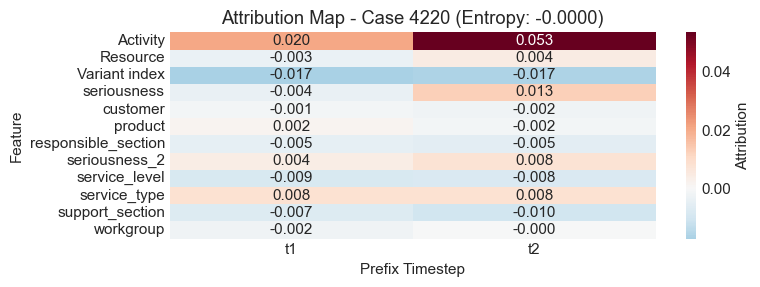


────────────────────────────────────────────────────────────
CASE 2
────────────────────────────────────────────────────────────
Case: Case 4461
Prefix Length: 2
Brier Score: 0.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.719416


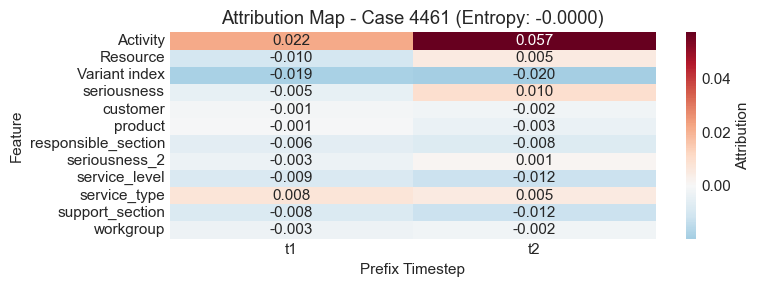


────────────────────────────────────────────────────────────
CASE 3
────────────────────────────────────────────────────────────
Case: Case 826
Prefix Length: 2
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. None
  2. Resolve ticket
  3. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -1.105448


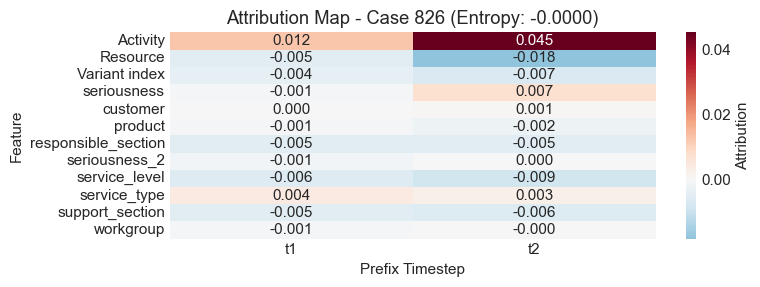


────────────────────────────────────────────────────────────
CASE 4
────────────────────────────────────────────────────────────
Case: Case 826
Prefix Length: 3
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket
  3. None

True Suffix:
  1. Resolve ticket
  2. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.695878


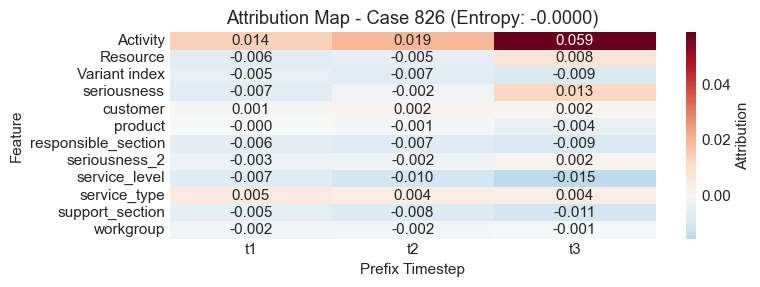


────────────────────────────────────────────────────────────
CASE 5
────────────────────────────────────────────────────────────
Case: Case 510
Prefix Length: 2
Brier Score: 1.0000
Shannon Entropy: -0.0000

Prefix Events:
  1. Assign seriousness
  2. Take in charge ticket

True Suffix:
  1. None
  2. Resolve ticket
  3. Closed

Mean Prediction:
  1. Resolve ticket
  2. Closed


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(



Convergence Delta: -0.894557


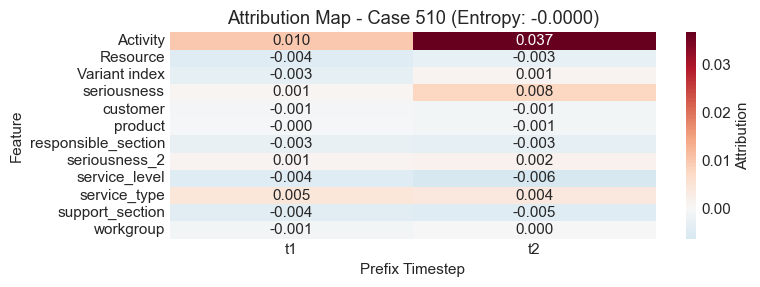

In [22]:
print("=" * 80)
print("BOTTOM 5 LEAST CERTAIN PREDICTIONS (Highest Shannon Entropy)")
print("=" * 80)

for idx, (_, row) in enumerate(bottom5_certain.iterrows()):
    print(f"\n{'─' * 60}")
    print(f"CASE {idx + 1}")
    print(f"{'─' * 60}")
    
    display_case_info(row)
    
    try:
        result = analyze_prefix_attributions(row, model, evaluation, prefix_cat_attributes)
        print(f"\nConvergence Delta: {result['convergence_delta']:.6f}")
        
        fig, ax = plt.subplots(figsize=(max(8, result['prefix_len'] * 2), 3))
        visualize_attribution_heatmap(
            result['attribution_list'],
            title=f"Attribution Map - {row['case_name']} (Entropy: {row['shannon_entropy_activities']:.4f})",
            ax=ax
        )
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error computing attributions: {e}")

---
## Section 1d: Attribution Breakdown by Predicted Activity Class

For each activity the model can predict, we analyze what input features drive that prediction. This helps understand:
- Which features are most important for predicting specific activities
- Whether the model relies on different features for different activity types
- Potential biases in how the model uses input information

In [23]:
# Get activity class information from the dataset
# all_categories structure: ([cat_categories], [num_categories])
# Each cat_category is: (column_name, num_classes, {class_name: class_idx})
cat_categories = helpdesk_test_dataset.all_categories[0]
activity_info = cat_categories[0]  # First categorical feature is Activity

activity_name_col = activity_info[0]  # Column name
n_activities = activity_info[1]  # Number of classes
activity_idx_map = activity_info[2]  # Dict: activity_name -> activity_idx

# Invert the mapping to get idx -> name
activity_classes = {v: k for k, v in activity_idx_map.items()}

print(f"Activity column: {activity_name_col}")
print(f"Number of activity classes: {n_activities}")
print(f"\nActivity classes:")
for idx in sorted(activity_classes.keys()):
    print(f"  {idx}: {activity_classes[idx]}")

Activity column: Activity
Number of activity classes: 16

Activity classes:
  1: Assign seriousness
  2: Closed
  3: Create SW anomaly
  4: DUPLICATE
  5: EOS
  6: INVALID
  7: Insert ticket
  8: RESOLVED
  9: Require upgrade
  10: Resolve SW anomaly
  11: Resolve ticket
  12: Schedule intervention
  13: Take in charge ticket
  14: VERIFIED
  15: Wait


In [24]:
def compute_attributions_for_all_activities(prefix, prefix_len, model, prefix_cat_attributes, 
                                             n_activities, n_steps=100):
    """
    Compute attributions for each possible activity prediction.
    
    Args:
        prefix: Input prefix tensor
        prefix_len: Length of the prefix
        model: The trained model
        prefix_cat_attributes: List of categorical attribute names
        n_activities: Number of activity classes
        n_steps: Number of IG steps (reduced for efficiency)
    
    Returns:
        dict: activity_idx -> dict of feature attributions
    """
    activity_attributions = {}
    
    for activity_idx in range(n_activities):
        try:
            # Create targeter for this activity
            activity_targeter = ActivityTargeter(activity_index=activity_idx)
            
            # Compute IG
            attributions, conv_delta = compute_integrated_gradients(
                model=model,
                prefix=prefix,
                target_fn=activity_targeter.target_fn,
                n_steps=n_steps,
                method='gausslegendre'
            )
            
            # Unpack attributions
            attribution_list = get_attribution_for_prefix(
                attributions, prefix_len, model, prefix_cat_attributes
            )
            
            # Aggregate across timesteps (mean absolute attribution per feature)
            feature_attrs = {}
            for attr_dict in attribution_list:
                for feature, value in attr_dict.items():
                    if feature not in feature_attrs:
                        feature_attrs[feature] = []
                    feature_attrs[feature].append(abs(value))
            
            activity_attributions[activity_idx] = {k: np.mean(v) for k, v in feature_attrs.items()}
            
        except Exception as e:
            print(f"  Error for activity {activity_idx}: {e}")
            activity_attributions[activity_idx] = None
    
    return activity_attributions

In [25]:
# Sample prefixes and compute attributions targeting each activity class
# We'll use a small sample due to computational cost (n_activities * n_samples * IG computations)

SAMPLE_SIZE_ACTIVITY = 10  # Number of prefixes to sample
N_STEPS_ACTIVITY = 100  # Reduced steps for efficiency

# Sample diverse prefixes
sample_activity_df = valid_df.sample(n=min(SAMPLE_SIZE_ACTIVITY, len(valid_df)), random_state=SEED)

print(f"Computing attributions for {len(sample_activity_df)} prefixes × {n_activities} activities...")
print(f"Total IG computations: {len(sample_activity_df) * n_activities}")

# Store results: for each activity, aggregate attributions across all sample prefixes
activity_feature_attributions = {idx: [] for idx in range(n_activities)}

for sample_idx, (_, row) in enumerate(tqdm(sample_activity_df.iterrows(), 
                                            total=len(sample_activity_df), 
                                            desc="Processing prefixes")):
    try:
        prefix = get_prefix_tensor_from_row(row, evaluation)
        prefix_len = row['prefix_len']
        
        # Compute attributions for all activities
        all_activity_attrs = compute_attributions_for_all_activities(
            prefix, prefix_len, model, prefix_cat_attributes, 
            n_activities, n_steps=N_STEPS_ACTIVITY
        )
        
        # Store results
        for activity_idx, attrs in all_activity_attrs.items():
            if attrs is not None:
                activity_feature_attributions[activity_idx].append(attrs)
                
    except Exception as e:
        print(f"Error for {row['case_name']}: {e}")

print(f"\nCompleted. Samples per activity: {[len(v) for v in activity_feature_attributions.values()]}")

Computing attributions for 10 prefixes × 16 activities...
Total IG computations: 160


Processing prefixes:   0%|          | 0/10 [00:00<?, ?it/s]/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 18 equal to the number of examples.
  warnings.warn(
Processing prefixes: 100%|██████████| 10/10 [05:34<00:00, 33.47s/it]


Completed. Samples per activity: [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


In [26]:
# Aggregate attributions by activity class
activity_aggregated = {}

for activity_idx in range(n_activities):
    attrs_list = activity_feature_attributions[activity_idx]
    
    if len(attrs_list) > 0:
        # Get all feature names
        feature_names = attrs_list[0].keys()
        
        # Average across all samples
        activity_aggregated[activity_idx] = {
            feat: np.mean([a[feat] for a in attrs_list if feat in a])
            for feat in feature_names
        }
    else:
        activity_aggregated[activity_idx] = None

# Display aggregated results
print("=" * 80)
print("FEATURE ATTRIBUTION BY PREDICTED ACTIVITY")
print("=" * 80)

for activity_idx, attrs in activity_aggregated.items():
    activity_name = activity_classes.get(activity_idx, f"Activity_{activity_idx}")
    print(f"\n{activity_name} (idx={activity_idx}):")
    
    if attrs is not None:
        # Sort by attribution value (descending)
        sorted_attrs = sorted(attrs.items(), key=lambda x: x[1], reverse=True)
        for feat, val in sorted_attrs[:5]:  # Top 5 features
            print(f"  {feat:25s}: {val:.6f}")
    else:
        print("  No data available")

FEATURE ATTRIBUTION BY PREDICTED ACTIVITY

Activity_0 (idx=0):
  Activity                 : 0.011265
  Resource                 : 0.001404
  Variant index            : 0.000975
  service_level            : 0.000834
  seriousness              : 0.000729

Assign seriousness (idx=1):
  Activity                 : 0.016645
  service_level            : 0.004009
  support_section          : 0.003473
  Variant index            : 0.003340
  seriousness              : 0.003046

Closed (idx=2):
  Activity                 : 0.044371
  Variant index            : 0.008622
  service_level            : 0.008618
  support_section          : 0.007477
  seriousness              : 0.006629

Create SW anomaly (idx=3):
  Activity                 : 0.010179
  service_level            : 0.003064
  support_section          : 0.002707
  Variant index            : 0.002703
  seriousness              : 0.002441

DUPLICATE (idx=4):
  Activity                 : 0.004723
  Resource                 : 0.001025
  Varia

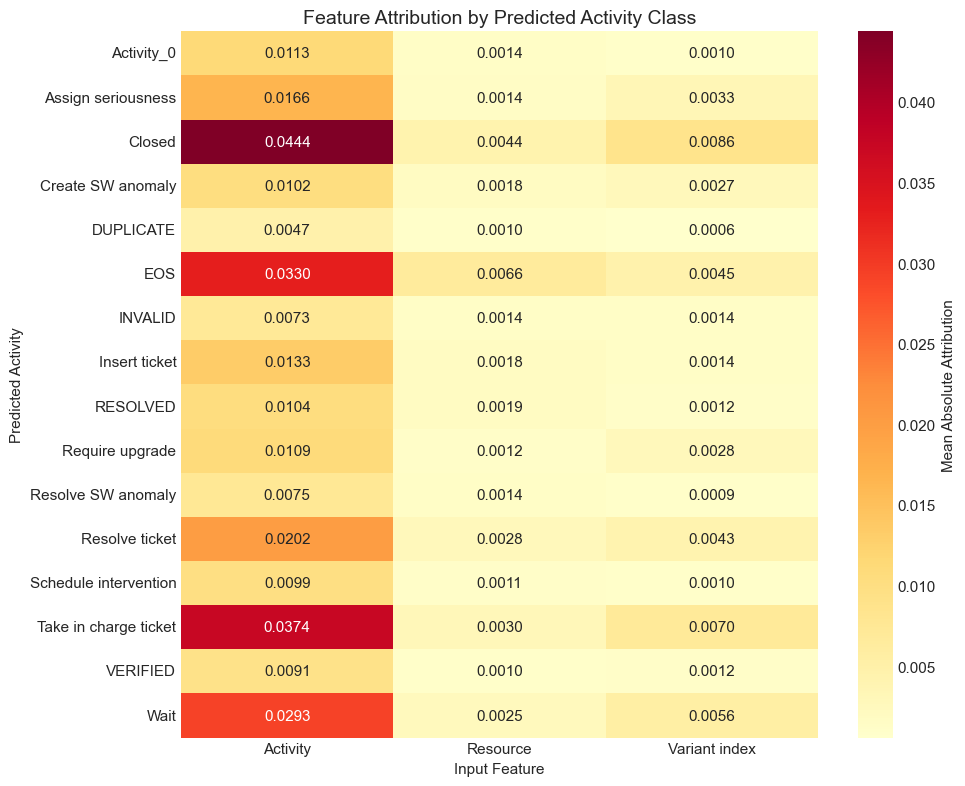

In [27]:
# Visualization 1: Heatmap of feature attributions by activity
# Build matrix for heatmap
valid_activities = [idx for idx, attrs in activity_aggregated.items() if attrs is not None]

if valid_activities:
    # Use only the main features for clarity
    main_features = ['Activity', 'Resource', 'Variant index']
    available_features = [f for f in main_features if f in list(activity_aggregated[valid_activities[0]].keys())]
    
    # Build data matrix
    heatmap_data = []
    activity_labels = []
    
    for activity_idx in valid_activities:
        attrs = activity_aggregated[activity_idx]
        row_data = [attrs.get(f, 0) for f in available_features]
        heatmap_data.append(row_data)
        activity_labels.append(activity_classes.get(activity_idx, f"Activity_{activity_idx}"))
    
    heatmap_df = pd.DataFrame(heatmap_data, columns=available_features, index=activity_labels)
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, max(6, len(valid_activities) * 0.5)))
    
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt='.4f',
        cmap='YlOrRd',
        ax=ax,
        cbar_kws={'label': 'Mean Absolute Attribution'}
    )
    
    ax.set_title('Feature Attribution by Predicted Activity Class', fontsize=14)
    ax.set_xlabel('Input Feature')
    ax.set_ylabel('Predicted Activity')
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid activity attributions to visualize.")

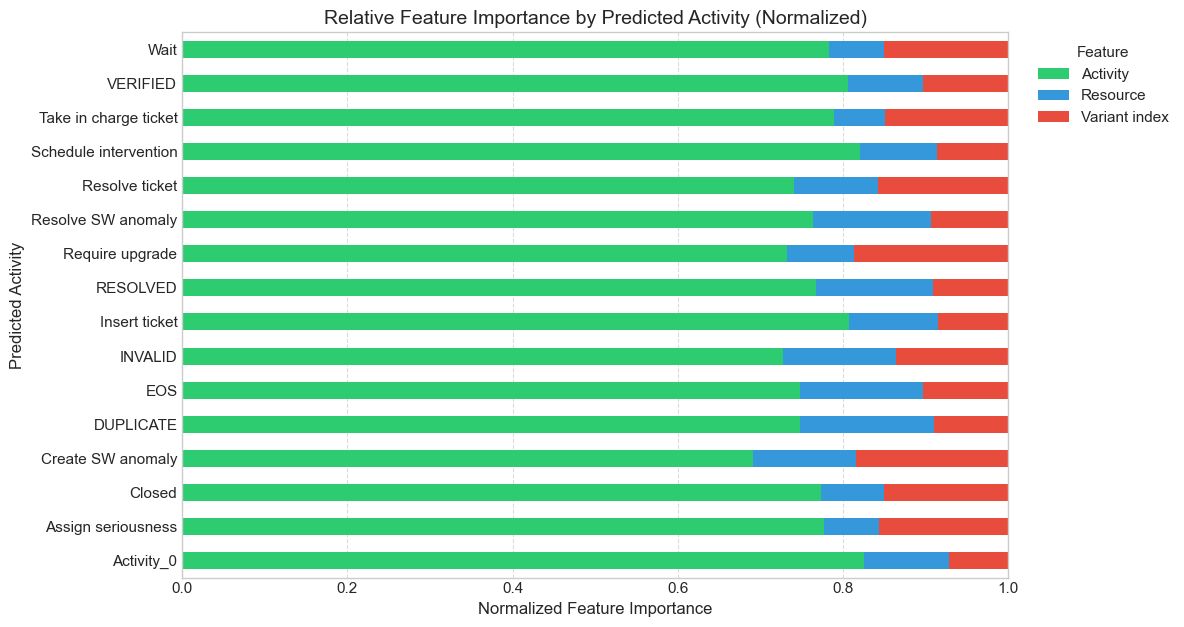

In [28]:
# Visualization 2: Normalized stacked bar chart
# Shows relative feature importance for each activity

if valid_activities and len(available_features) > 0:
    # Normalize each activity's attributions to sum to 1
    normalized_data = []
    
    for activity_idx in valid_activities:
        attrs = activity_aggregated[activity_idx]
        values = [attrs.get(f, 0) for f in available_features]
        total = sum(values) if sum(values) > 0 else 1
        normalized_data.append([v / total for v in values])
    
    normalized_df = pd.DataFrame(normalized_data, columns=available_features, index=activity_labels)
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(12, max(6, len(valid_activities) * 0.4)))
    
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']
    normalized_df.plot(kind='barh', stacked=True, ax=ax, color=colors[:len(available_features)])
    
    ax.set_xlabel('Normalized Feature Importance', fontsize=12)
    ax.set_ylabel('Predicted Activity', fontsize=12)
    ax.set_title('Relative Feature Importance by Predicted Activity (Normalized)', fontsize=14)
    ax.legend(title='Feature', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_xlim(0, 1)
    
    # Add grid
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid activity attributions to visualize.")

In [29]:
# Analysis: Key insights from activity-specific attributions
print("=" * 80)
print("KEY INSIGHTS: Activity-Feature Relationships")
print("=" * 80)

if valid_activities:
    # For each feature, find which activity relies on it most
    print("\n1. Which activity relies MOST on each feature?")
    print("-" * 60)
    
    for feature in available_features:
        max_activity = None
        max_value = 0
        
        for activity_idx in valid_activities:
            attrs = activity_aggregated[activity_idx]
            if attrs and feature in attrs:
                if attrs[feature] > max_value:
                    max_value = attrs[feature]
                    max_activity = activity_classes.get(activity_idx, f"Activity_{activity_idx}")
        
        if max_activity:
            print(f"  {feature:20s} → {max_activity} (attribution: {max_value:.6f})")
    
    # For each activity, find which feature is most important
    print("\n2. Which feature is MOST important for each activity?")
    print("-" * 60)
    
    for activity_idx in valid_activities:
        attrs = activity_aggregated[activity_idx]
        if attrs:
            # Find top feature
            top_feature = max(attrs.items(), key=lambda x: x[1])
            
            # Calculate relative importance
            total = sum(attrs.values())
            relative_pct = (top_feature[1] / total * 100) if total > 0 else 0
            
            activity_name = activity_classes.get(activity_idx, f"Activity_{activity_idx}")
            print(f"  {activity_name:25s} → {top_feature[0]} ({relative_pct:.1f}% of total attribution)")
    
    # Find activities with unusual feature patterns
    print("\n3. Activities with distinct feature patterns:")
    print("-" * 60)
    
    # Calculate mean feature importance across all activities
    mean_feature_importance = {}
    for feature in available_features:
        values = []
        for activity_idx in valid_activities:
            attrs = activity_aggregated[activity_idx]
            if attrs and feature in attrs:
                total = sum(attrs.values())
                if total > 0:
                    values.append(attrs[feature] / total)
        mean_feature_importance[feature] = np.mean(values) if values else 0
    
    # Find activities that deviate from the mean
    for activity_idx in valid_activities:
        attrs = activity_aggregated[activity_idx]
        if attrs:
            total = sum(attrs.values())
            if total > 0:
                deviations = []
                for feature in available_features:
                    actual = attrs.get(feature, 0) / total
                    expected = mean_feature_importance[feature]
                    deviation = actual - expected
                    if abs(deviation) > 0.1:  # 10% threshold
                        direction = "more" if deviation > 0 else "less"
                        deviations.append(f"{direction} {feature}")
                
                if deviations:
                    activity_name = activity_classes.get(activity_idx, f"Activity_{activity_idx}")
                    print(f"  {activity_name}: relies {', '.join(deviations)} than average")
else:
    print("No valid activity attributions to analyze.")

KEY INSIGHTS: Activity-Feature Relationships

1. Which activity relies MOST on each feature?
------------------------------------------------------------
  Activity             → Closed (attribution: 0.044371)
  Resource             → EOS (attribution: 0.006569)
  Variant index        → Closed (attribution: 0.008622)

2. Which feature is MOST important for each activity?
------------------------------------------------------------
  Activity_0                → Activity (63.6% of total attribution)
  Assign seriousness        → Activity (41.2% of total attribution)
  Closed                    → Activity (45.2% of total attribution)
  Create SW anomaly         → Activity (34.3% of total attribution)
  DUPLICATE                 → Activity (55.0% of total attribution)
  EOS                       → Activity (54.2% of total attribution)
  INVALID                   → Activity (42.3% of total attribution)
  Insert ticket             → Activity (61.8% of total attribution)
  RESOLVED           

---
## Summary

### Key Findings

Document your observations here after running the notebook:

1. **Attribution patterns for accurate predictions (low Brier):**
   - [Your observations]

2. **Attribution patterns for inaccurate predictions (high Brier):**
   - [Your observations]

3. **Feature importance trends across quality quartiles:**
   - [Your observations]

4. **Attribution patterns for certain predictions (low entropy):**
   - [Your observations]

5. **Attribution patterns for uncertain predictions (high entropy):**
   - [Your observations]

6. **Activity-specific feature dependencies:**
   - Which activities rely most on Activity history vs Resource vs other features?
   - Are there activities with distinct attribution patterns?
   - [Your observations]

In [30]:
# Optionally save computed attribution results
# if 'attribution_df' in dir() and not use_precomputed:
#     with open('attribution_analysis_results.pkl', 'wb') as f:
#         pickle.dump(attribution_df, f)
#     print("Results saved to attribution_analysis_results.pkl")